<a href="https://colab.research.google.com/github/sauraviitj/HopeLens/blob/main/scripts/03_Hope_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install sentence-transformers

In [ ]:
import os
import re
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [ ]:
model = SentenceTransformer(
    "sentence-transformers/all-mpnet-base-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH="/content/drive/MyDrive/HopeLens"

MODEL_PATH=os.path.join(BASE_PATH,"models")

DATA_PATH=os.path.join(BASE_PATH,"Data")

LYRICS_PATH=os.path.join(DATA_PATH,"Lyrics")

songs=pd.read_csv(
    os.path.join(
        DATA_PATH,
        "metadata",
        "song_semantic.csv"
    )
)

In [ ]:
hope_vector=np.load(
    os.path.join(
        MODEL_PATH,
        "hope_vector.npy"
    )
)

despair_vector=np.load(
    os.path.join(
        MODEL_PATH,
        "despair_vector.npy"
    )
)

In [ ]:
hope_axis=hope_vector-despair_vector

hope_axis=hope_axis/np.linalg.norm(
    hope_axis
)

print(hope_axis.shape)

(768,)


In [ ]:
def read_song(path):

    with open(
        path,
        encoding="utf8"
    ) as f:

        lines=[
            x.strip()
            for x in f.readlines()
            if x.strip()
        ]

    return lines

In [ ]:
def semantic_hope(lines):

    emb=model.encode(
        lines,
        convert_to_numpy=True
    )

    emb=emb/np.linalg.norm(
        emb,
        axis=1,
        keepdims=True
    )

    projection=np.dot(
        emb,
        hope_axis
    )

    projection=(projection+1)/2

    projection*=100

    return projection

In [ ]:
lines=read_song(
    os.path.join(
        LYRICS_PATH,
        "fix_you.txt"
    )
)

scores=semantic_hope(lines)

for l,s in zip(lines,scores):

    print(
        f"{s:.2f}",
        l
    )

50.02 When you try your best, but you don't succeed
46.31 When you get what you want, but not what you need
44.40 When you feel so tired, but you can't sleep
41.77 Stuck in reverse
57.69 And the tears come streaming down your face
42.52 When you lose something you can't replace
44.59 When you love someone, but it goes to waste
39.13 Could it be worse?
51.68 Lights will guide you home
55.97 And ignite your bones
53.56 And I will try to fix you
52.69 And high up above or down below
52.67 When you're too in love to let it go
50.70 But if you never try, you'll never know
50.80 Just what you're worth
51.68 Lights will guide you home
55.97 And ignite your bones
53.56 And I will try to fix you
51.02 Tears stream down your face
41.21 When you lose something you cannot replace
56.83 Tears stream down your face, and I
51.02 Tears stream down your face
57.17 I promise you I will learn from my mistakes
56.83 Tears stream down your face, and I
51.68 Lights will guide you home
55.97 And ignite your 

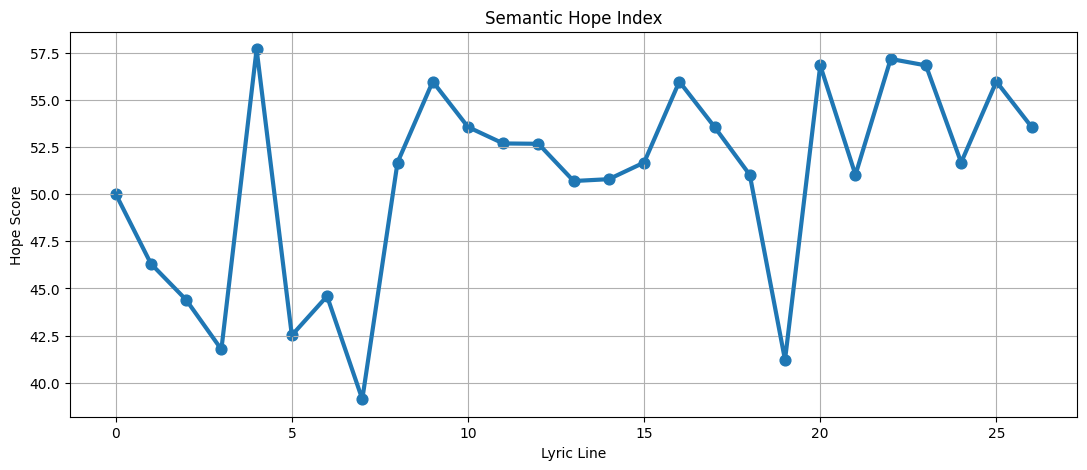

In [ ]:
plt.figure(figsize=(13,5))

plt.plot(
    scores,
    linewidth=3
)

plt.scatter(
    range(len(scores)),
    scores,
    s=60
)

plt.title(
    "Semantic Hope Index"
)

plt.xlabel(
    "Lyric Line"
)

plt.ylabel(
    "Hope Score"
)

plt.grid()

plt.show()

In [ ]:
ai_scores=[]

for _,row in songs.iterrows():

    lines=read_song(

        os.path.join(
            LYRICS_PATH,
            row["filename"]
        )

    )

    score=semantic_hope(
        lines
    )

    ai_scores.append(
        score.mean()
    )

songs["AI Score"]=ai_scores

In [ ]:
songs.sort_values(
    "AI Score",
    ascending=False
)[
    [
        "Song",
        "AI Score"
    ]
]

,Song,AI Score
14,Young at Heart,55.623901
17,Nature Boy,55.481594
15,Smile,55.257870
9,Hall of Fame,55.120640
1,Up&Up,54.788059
8,Rise Up,54.784916
16,L-O-V-E,54.272217
4,Everglow,54.268440
12,My Way,54.037708
13,Fly Me to the Moon,53.482609


In [ ]:
def extract_trajectory_features(scores):

    scores = np.array(scores)

    features = {

        "mean": np.mean(scores),

        "median": np.median(scores),

        "max": np.max(scores),

        "min": np.min(scores),

        "std": np.std(scores),

        "start": scores[0],

        "end": scores[-1],

        "growth": scores[-1] - scores[0],

        "peak_position": np.argmax(scores),

        "valley_position": np.argmin(scores),

        "auc": np.trapz(scores)

    }

    return features

In [ ]:
features = extract_trajectory_features(scores)

for k, v in features.items():
    print(f"{k:15s}: {v}")

mean           : 50.77876281738281
median         : 51.679527282714844
max            : 57.68882751464844
min            : 39.12647247314453
std            : 5.278651237487793
start          : 50.01608657836914
end            : 53.564842224121094
growth         : 3.548755645751953
peak_position  : 4
valley_position: 7
auc            : 1319.236083984375


/tmp/ipykernel_22021/2676493448.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "auc": np.trapz(scores)


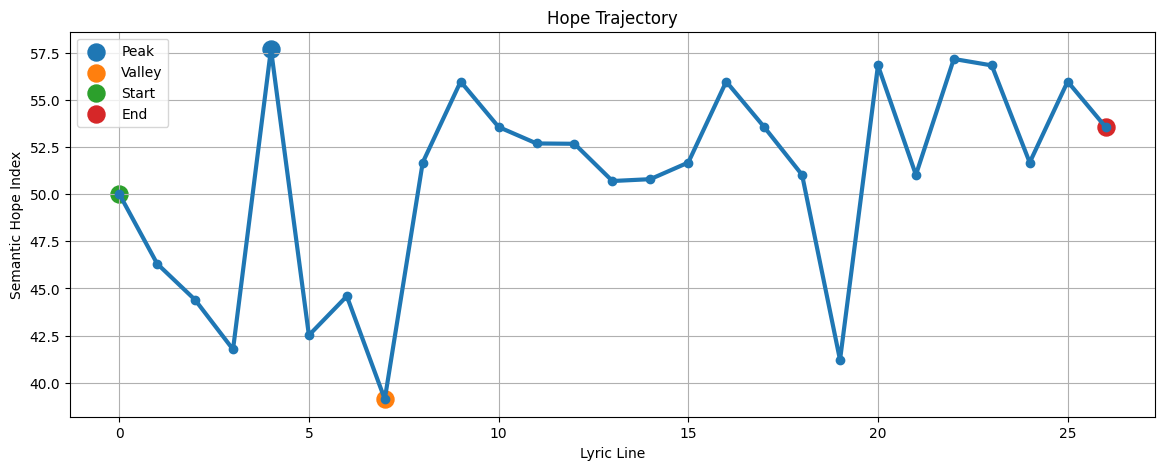

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(scores,
         linewidth=3,
         marker="o")

plt.scatter(
    np.argmax(scores),
    np.max(scores),
    s=150,
    label="Peak"
)

plt.scatter(
    np.argmin(scores),
    np.min(scores),
    s=150,
    label="Valley"
)

plt.scatter(
    0,
    scores[0],
    s=150,
    label="Start"
)

plt.scatter(
    len(scores)-1,
    scores[-1],
    s=150,
    label="End"
)

plt.xlabel("Lyric Line")

plt.ylabel("Semantic Hope Index")

plt.title("Hope Trajectory")

plt.grid(True)

plt.legend()

plt.show()

In [ ]:
feature_list = []

for _, row in songs.iterrows():

    lines = read_song(
        os.path.join(
            LYRICS_PATH,
            row["filename"]
        )
    )

    score = semantic_hope(lines)

    feat = extract_trajectory_features(score)

    feat["Song"] = row["Song"]

    feature_list.append(feat)

trajectory_df = pd.DataFrame(feature_list)

trajectory_df.head()

/tmp/ipykernel_22021/2676493448.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "auc": np.trapz(scores)


,mean,median,max,min,std,start,end,growth,peak_position,valley_position,auc,Song
0,50.778763,51.679527,57.688828,39.126472,5.278651,50.016087,53.564842,3.548756,4,7,1319.236084,Fix You
1,54.788059,55.547367,60.649616,45.666714,3.270549,53.691132,50.715374,-2.975758,16,21,3618.596680,Up&Up
2,50.544090,50.385342,55.747368,44.963818,2.516300,53.012554,53.408718,0.396164,15,29,1564.200317,Paradise
3,52.277119,52.893562,62.424068,46.041321,3.184599,53.217201,46.041321,-7.175880,18,25,1309.575684,The Scientist
4,54.268440,54.877205,64.526657,44.105045,4.058446,55.952202,52.850819,-3.101383,20,7,1465.114746,Everglow


In [ ]:
trajectory_df["SHI"] = (

    0.30 * trajectory_df["mean"]

    + 0.30 * trajectory_df["end"]

    + 0.25 * trajectory_df["growth"]

    + 0.15 * trajectory_df["max"]

)

In [ ]:
trajectory_df.sort_values(
    "SHI",
    ascending=False
)[
    [
        "Song",
        "SHI",
        "growth",
        "end",
        "max"
    ]
]

,Song,SHI,growth,end,max
5,Yellow,49.736237,21.124115,64.246094,64.246094
17,Nature Boy,45.594173,6.785477,59.959389,61.770035
12,My Way,44.182564,5.545498,56.135262,64.961952
16,L-O-V-E,44.128593,7.769276,57.016479,58.664417
6,What a Wonderful World,43.826973,7.770329,56.677200,59.122265
8,Rise Up,43.505814,8.385944,52.440567,61.611183
13,Fly Me to the Moon,42.942768,6.167576,56.346874,56.346874
15,Smile,42.244324,-2.506325,55.302639,64.685020
4,Everglow,41.039436,-3.101383,52.850819,64.526657
14,Young at Heart,40.941223,-4.031006,53.267933,61.876137


In [ ]:
trajectory_df.to_csv(

    os.path.join(
        BASE_PATH,
        "results",
        "semantic_hope_index.csv"
    ),

    index=False

)

In [ ]:
comparison = trajectory_df[["Song", "mean", "SHI"]].copy()

comparison = comparison.sort_values(
    "SHI",
    ascending=False
)

comparison

,Song,mean,SHI
5,Yellow,51.814884,49.736237
17,Nature Boy,55.481594,45.594173
12,My Way,54.037708,44.182564
16,L-O-V-E,54.272217,44.128593
6,What a Wonderful World,53.376297,43.826973
8,Rise Up,54.784916,43.505814
13,Fly Me to the Moon,53.482609,42.942768
15,Smile,55.257870,42.244324
4,Everglow,54.268440,41.039436
14,Young at Heart,55.623901,40.941223


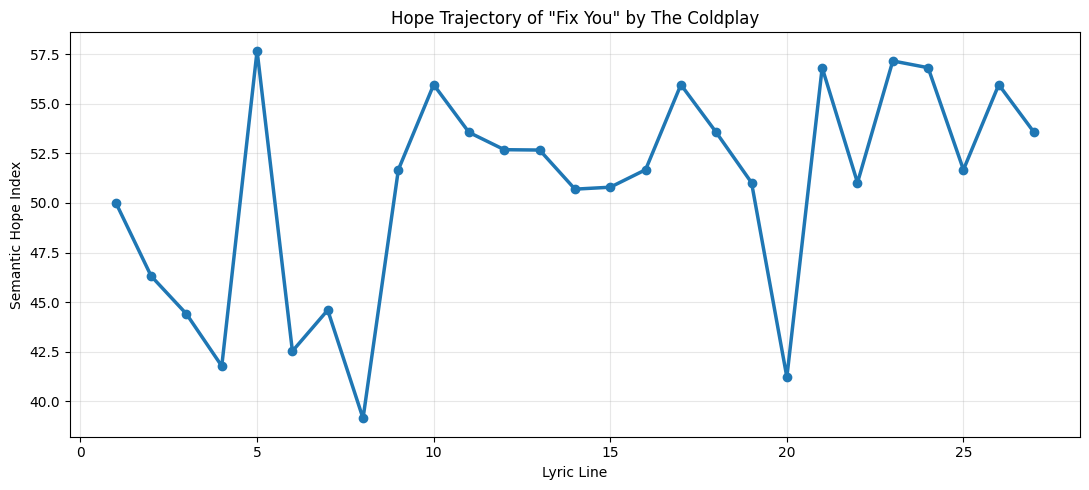

In [ ]:
plt.figure(figsize=(11,5))

plt.plot(
    range(1, len(scores)+1),
    scores,
    marker='o',
    linewidth=2.5
)

plt.xlabel("Lyric Line")
plt.ylabel("Semantic Hope Index")
plt.title('Hope Trajectory of "Fix You" by The Coldplay')

plt.grid(alpha=0.3)

plt.tight_layout()